 # Process Annotated Data for NER & RE

 Translate Label Studio JSON files to a format for ML.

In [47]:
import json
import ast
from datetime import datetime
from collections import defaultdict, Counter
from typing import Any, Dict
from dataclasses import dataclass
from itertools import combinations
import random
import copy

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import spacy
from spacy.tokens import Span
from spacy import displacy


In [49]:
# Local imports
import sys
from pathlib import Path

# NOTE: A bit of a hack to get relative paths to work
sys.path.append(str(Path.cwd().parent.parent / "src"))
from common.paths import RAW, PROCESSED
from common.graph_helpers import analyze_category_distribution_from_dict, plot_cooccurrence_heatmap
from common.logging import setup_logger
from common.json_helpers import save_json
from eval.evaluators import SpanEvaluator


In [28]:
@dataclass
class Config:
    logger = setup_logger('preprocessing.process_annotated_data')
    annotated_data_path = RAW / "annotations" / "annotated-gold-standard.json"
    taxonomy_path = PROCESSED / "taxonomy_autogen_v2.csv"
    output_path = PROCESSED / "gold_standard.json"
    
    random_state = 42
    person_labels = {"Person_Name", "Person_Role", "Person_Pronoun"}
    cat_labels = []

config = Config()


 ## 1. Import Data

In [29]:
with open(config.annotated_data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)
print(f"Total raw notes loaded: {len(data)}")

taxonomy = pd.read_csv(config.taxonomy_path)
config.cat_labels = set(taxonomy.cat_label.values.tolist())
taxonomy.head(5)


Total raw notes loaded: 2000


,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


 ## 2. Formatting & Extraction

 Strip out Label Studio Metadata, ensure spans are aligned with word boundaries.

In [30]:
def clean_span(text: str, start: int, end: int):
    '''Validates and cleans Label Studio character offsets.'''
    if start < 0 or end > len(text) or start >= end:
        return None

    # Expand boundaries if they split a word
    while start > 0 and text[start - 1].isalnum(): start -= 1
    while end < len(text) and text[end].isalnum(): end += 1

    span_text = text[start:end]
    cleaned = span_text.strip()
    if not cleaned: return None

    leading_whitespace = len(span_text) - len(span_text.lstrip())
    new_start = start + leading_whitespace
    
    return {"text": cleaned, "start": new_start, "end": new_start + len(cleaned)}

def extract_annotations(task: Dict[str, Any]) -> Dict[str, Any] | None:
    '''
    Extract annotations from Label Studio.
    Output schema: {id: uuid, text: str, needs: list(dict), persons: list(dict), relations: list(dict)}
    '''
    id = task["data"]["id"]
    text = task["data"]["note_content"]
    
    if not task["annotations"]:
        return None
        
    annotation = min(task["annotations"], key=lambda x: datetime.strptime(x["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ"))
    annotation_date = datetime.strptime(annotation["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ")
    
    needs, persons, relations = [], [], []
    seen_ids = set()

    for l in annotation["result"]:
        if l["type"] != "labels": continue
        
        ent_id = l["id"]
        label = l["value"]["labels"][0]
        span = clean_span(text, l["value"]["start"], l["value"]["end"])
        
        if not span: continue
        
        seen_ids.add(ent_id)
        item = {"id": ent_id, "text": span["text"], "start": span["start"], "end": span["end"], "label": label}

        if l["from_name"] == "need_labels" and label in config.cat_labels:
            needs.append(item)
        elif l["from_name"] == "entity_labels" and label in config.person_labels:
            persons.append(item)

    for l in annotation["result"]:
        if l["type"] == "relation" and l["from_id"] in seen_ids and l["to_id"] in seen_ids:
            relations.append({"from": l["from_id"], "to": l["to_id"]})

    return {
        "id": id,
        "label_studio_id": task['id'],
        "annotation_date": annotation_date,
        "text": text,
        "needs": needs,
        "persons": persons,
        "relations": relations,
    }

records = [r for r in (extract_annotations(task) for task in data) if r is not None]
records[2]


{'id': 'b7b3fb41-80b7-4d97-b8f4-0e0a7156ab79',
 'label_studio_id': 28102,
 'annotation_date': datetime.datetime(2026, 5, 19, 15, 19, 51, 661562),
 'text': '[Category: estateManagement] arson attack letter sent to tenant Dear  Resident\n\nSuspected Arson Attack   \n\nWe have been informed about a fire (suspected arson attack) which happened on <DATE_TIME> near the electrical cupboard at Whitelock House. Thank you all for your efforts on <DATE_TIME> in safely containing the fire and for contacting the emergency services. Please be reminded that we do not recommend attempting to control the fire if it is not safe to do so. \n\nWe appreciate the fire being so close to your home is worrying and hope this will not happen again. During my initial enquiries, I had the opportunity of speaking to other residents on <DATE_TIME> residing at Whitelock House who are concerned about the fire. \n\nPlease contact me if you have any specific information to assist in the enquiries and or if you have any 

 ## 3. EDA

 ### DisplaCy Visualizer

 Visualizing annotations is the fastest way to spot NER boundary errors or relation misalignments.

In [31]:

# Load a blank tokenizer
nlp = spacy.blank("en")

def visualize_overlapping_note(record):
    """Renders overlapping NER spans using Spacy's Span visualizer"""
    text = record['text']
    doc = nlp(text)
    
    spans = []
    # Combine and iterate through all entities
    for ent in record.get('needs', []) + record.get('persons', []):
        # spacy.blank allows us to easily convert char offsets to token spans
        span = doc.char_span(ent['start'], ent['end'], label=ent['label'])
        if span is not None:
            spans.append(span)
        else:
            print(f"Warning: Span '{ent['text']}' does not align with token boundaries.")
            
    # Add to a designated span group (e.g., 'sc' for span categorizer)
    doc.spans["sc"] = spans
    
    # Render using style="span"
    displacy.render(doc, style="span", jupyter=True)

# Test it out
visualize_overlapping_note(records[2])

 ### Relation Distances

 Analyzing how far apart linked entities are helps determine the context window size your RE model will need.

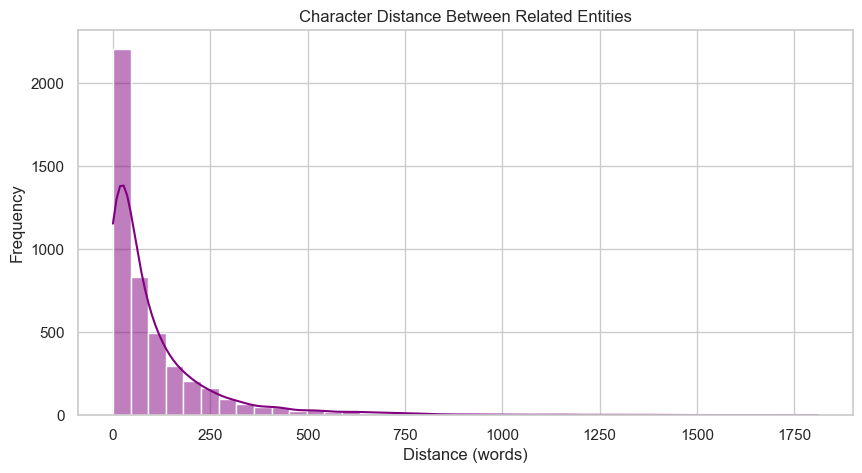

In [32]:
distances = []
for r in records:
    ents_by_id = {e['id']: e for e in r['needs'] + r['persons']}
    for rel in r['relations']:
        from_ent = ents_by_id.get(rel['from'])
        to_ent = ents_by_id.get(rel['to'])
        if from_ent and to_ent:
            dist = max(0, max(from_ent['start'], to_ent['start']) - min(from_ent['end'], to_ent['end']))
            distances.append(dist)

if distances:
    plt.figure(figsize=(10, 5))
    sns.histplot(distances, bins=40, kde=True, color='purple')
    plt.title('Character Distance Between Related Entities')
    plt.xlabel('Distance (words)')
    plt.ylabel('Frequency')
    plt.show()


### See which classes overlap most

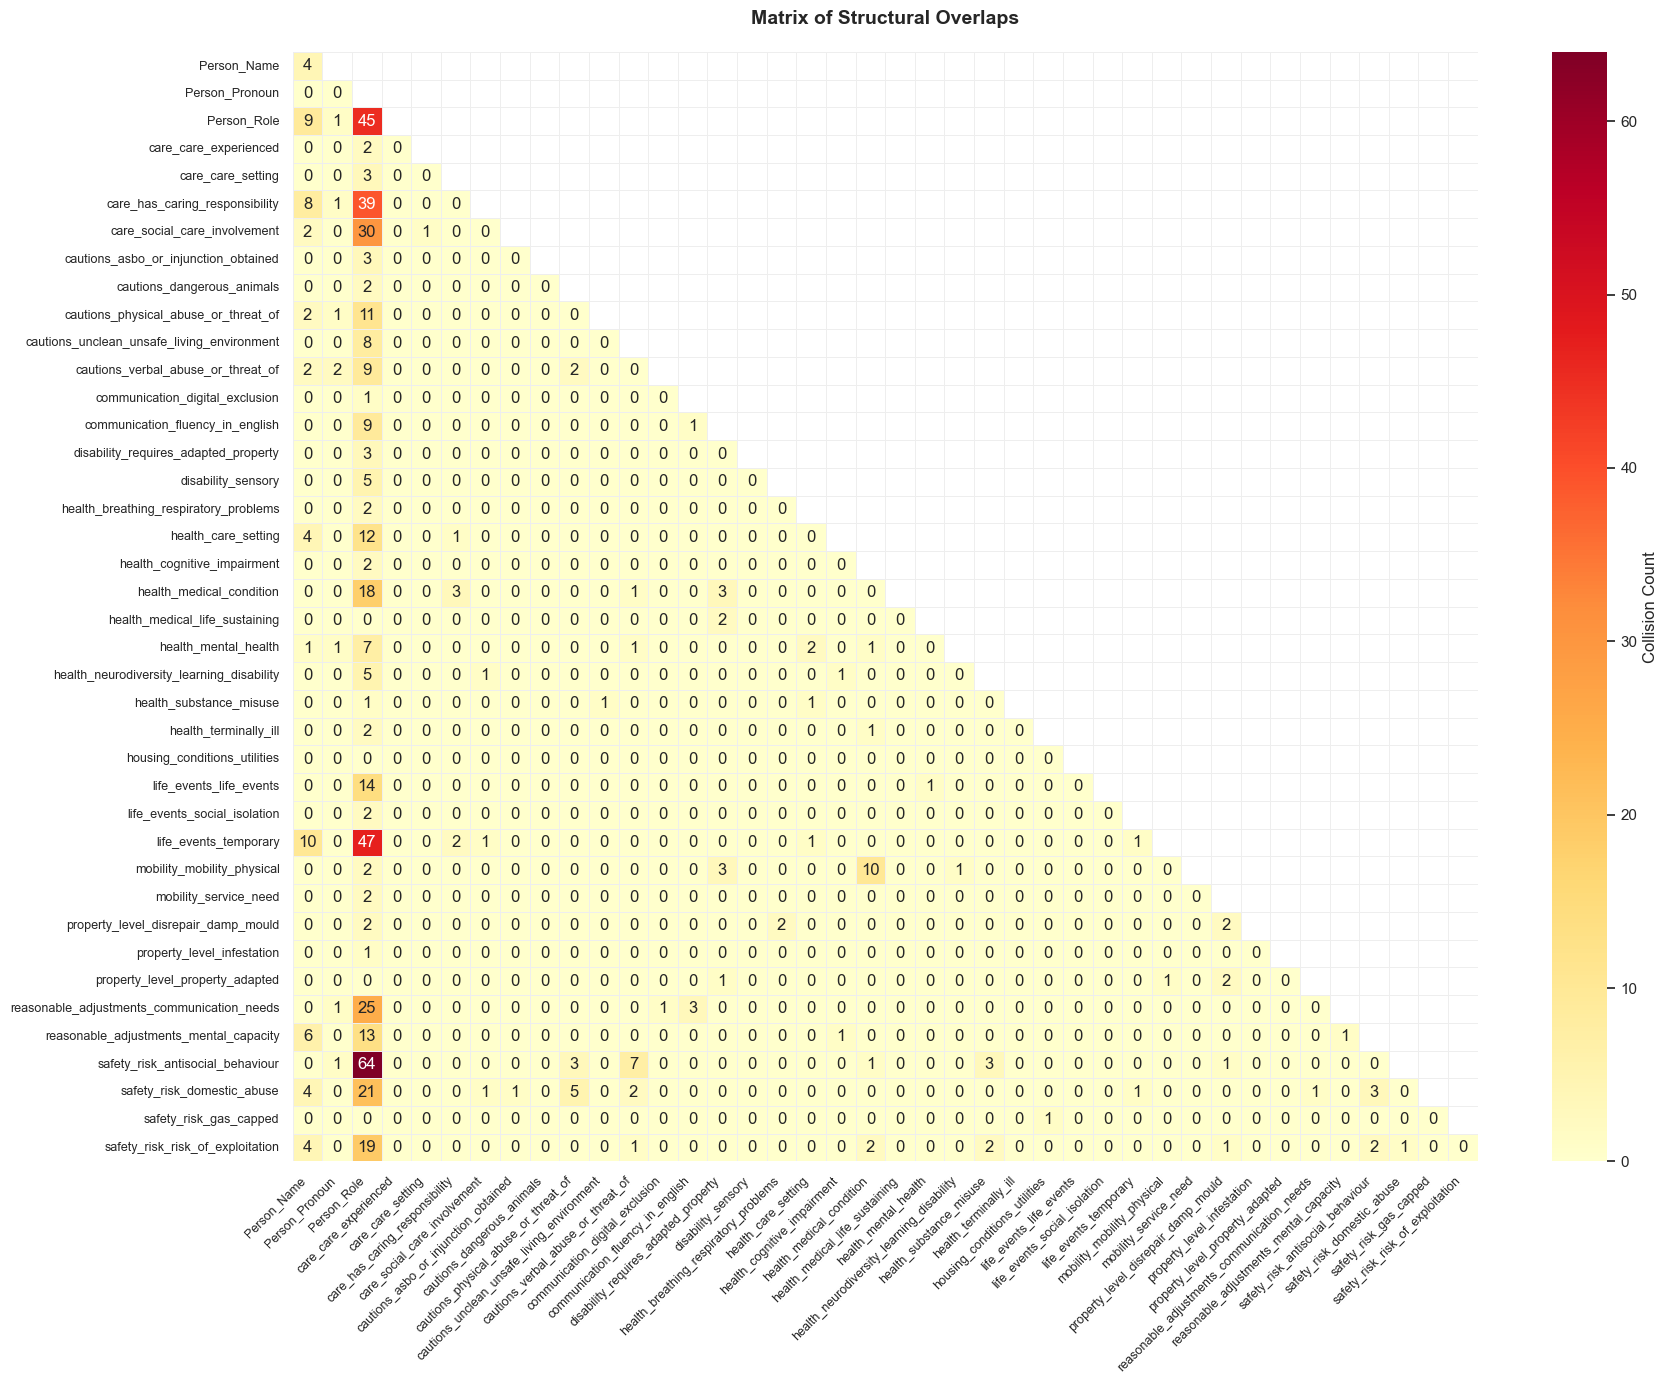

In [33]:
# 1. Track overlapping pairs
overlap_pairs_counts = defaultdict(int)
docs_with_overlaps = 0

for record in records:
    entities = record.get("needs", []) + record.get("persons", [])
    has_overlap = False
    
    for e1, e2 in combinations(entities, 2):
        if max(e1["start"], e2["start"]) < min(e1["end"], e2["end"]):
            has_overlap = True
            lbl_pair = tuple(sorted([e1["label"], e2["label"]]))
            overlap_pairs_counts[lbl_pair] += 1
            
    docs_with_overlaps += has_overlap

total_pairs = sum(overlap_pairs_counts.values())


# 2. Render Matrix and Heatmap (if overlaps exist)
if overlap_pairs_counts:
    labels = sorted({lbl for pair in overlap_pairs_counts for lbl in pair})
    overlap_matrix_df = pd.DataFrame(0, index=labels, columns=labels)

    # Populate symmetric matrix directly
    for (l1, l2), count in overlap_pairs_counts.items():
        overlap_matrix_df.loc[l1, l2] = overlap_matrix_df.loc[l2, l1] = count

    # Plot
    n = len(labels)
    plt.figure(figsize=(max(10, n * 0.45), max(8, n * 0.35)))
    sns.set_theme(style="white")
    
    mask = np.triu(np.ones(overlap_matrix_df.shape, dtype=bool), k=1)
    sns.heatmap(
        overlap_matrix_df, mask=mask, annot=True, fmt="d", cmap="YlOrRd", 
        cbar_kws={'label': 'Collision Count'}, linewidths=0.5, linecolor="#eeeeee"
    )
    
    plt.title("Matrix of Structural Overlaps", fontsize=14, pad=20, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

### Uh

/var/folders/gt/y9jpnfz10fg1twtr1558wcdh0000gp/T/ipykernel_49851/1257636723.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=person_types_in_rel, ax=axes[0, 0], palette="Blues_r")
/var/folders/gt/y9jpnfz10fg1twtr1558wcdh0000gp/T/ipykernel_49851/1257636723.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=relation_counts, ax=axes[0, 1], palette="magma")


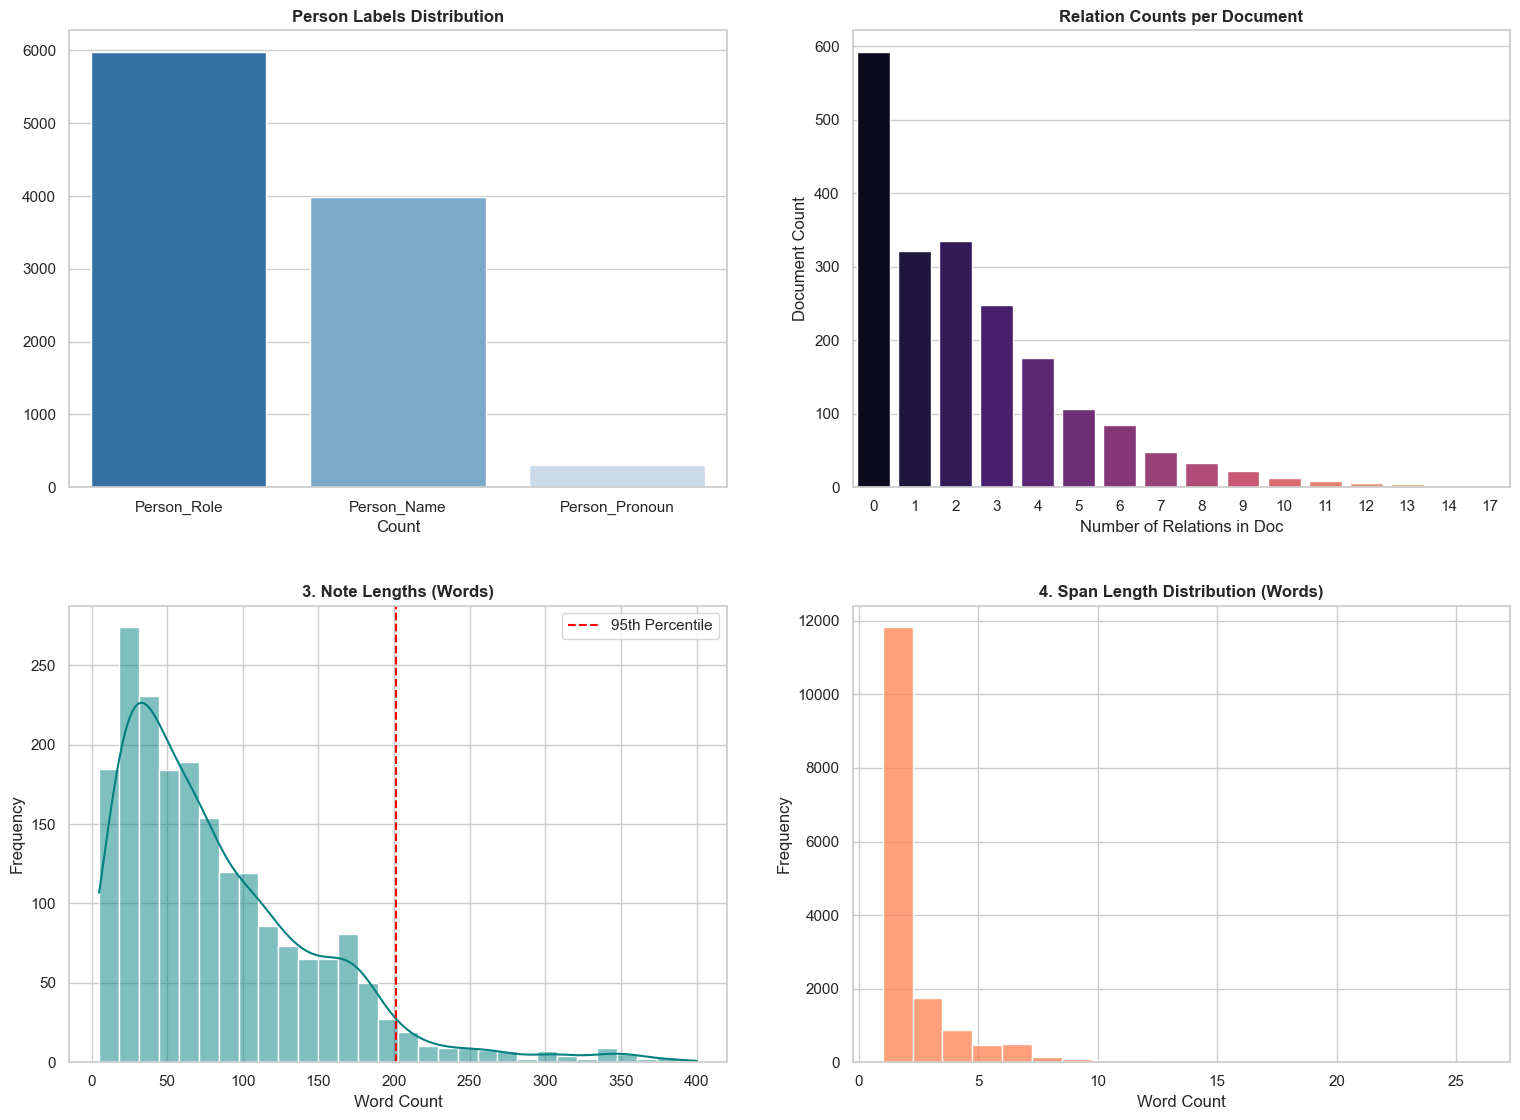

TEXT STATS SUMMARY
Note Word Count -> Median: 66 | 95th Percentile: 201 | Max: 400
Span Char Count -> Median: 2 | 95th Percentile: 6 | Max: 26


In [42]:
# Set up a 2x2 grid for our plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Person Label Counts
# ---------------------------------------------------------
person_types_in_rel = [p['label'] for r in records for p in r.get('persons', [])]
sns.countplot(x=person_types_in_rel, ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Person Labels Distribution", fontweight='bold')
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("")

# ---------------------------------------------------------
# 2. Relation Counts per Document
# ---------------------------------------------------------
relation_counts = [len(r.get("relations", [])) for r in records]
sns.countplot(x=relation_counts, ax=axes[0, 1], palette="magma")
axes[0, 1].set_title("Relation Counts per Document", fontweight='bold')
axes[0, 1].set_xlabel("Number of Relations in Doc")
axes[0, 1].set_ylabel("Document Count")

# ---------------------------------------------------------
# 3. Note Lengths (in Words)
# ---------------------------------------------------------
word_counts = [len(r["text"].split()) for r in records]
sns.histplot(word_counts, bins=30, ax=axes[1, 0], color="teal", kde=True)
axes[1, 0].axvline(np.percentile(word_counts, 95), color='red', linestyle='--', label='95th Percentile')
axes[1, 0].set_title("3. Note Lengths (Words)", fontweight='bold')
axes[1, 0].set_xlabel("Word Count")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

# ---------------------------------------------------------
# 4. Span Lengths (Words for all entities)
# ---------------------------------------------------------
span_lengths = [len(ent["text"].split()) for r in records for ent in r.get("needs", []) + r.get("persons", [])]
sns.histplot(span_lengths, bins=20, ax=axes[1, 1], color="coral")
axes[1, 1].set_title("4. Span Length Distribution (Words)", fontweight='bold')
axes[1, 1].set_xlabel("Word Count")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout(pad=3.0)
plt.show()

# Print out the text statistics for quick reference
print("=" * 60)
print("TEXT STATS SUMMARY")
print("=" * 60)
print(f"Note Word Count -> Median: {np.median(word_counts):.0f} | 95th Percentile: {np.percentile(word_counts, 95):.0f} | Max: {max(word_counts)}")
print(f"Span Char Count -> Median: {np.median(span_lengths):.0f} | 95th Percentile: {np.percentile(span_lengths, 95):.0f} | Max: {max(span_lengths)}")
print("=" * 60)

### Label Co-occurence

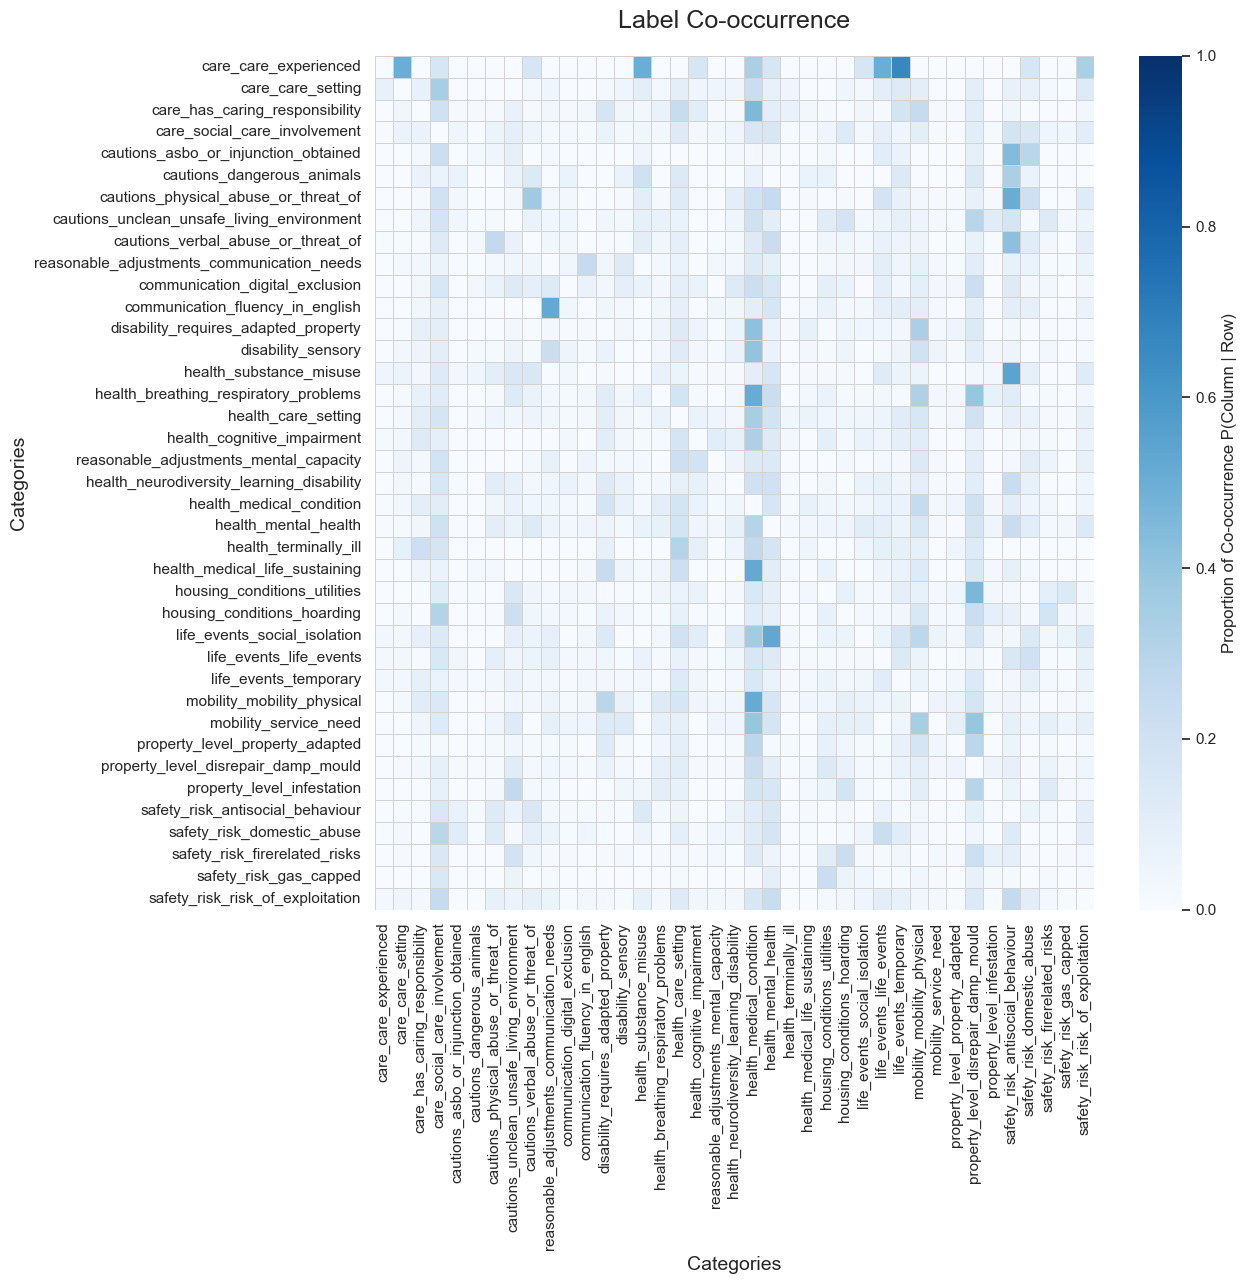

<Axes: title={'center': 'Label Co-occurrence'}, xlabel='Categories', ylabel='Categories'>

In [44]:
plot_cooccurrence_heatmap(records, taxonomy)

## Analyse label distribution

,label,frequency,IRLbl
0,health_medical_condition,317,1.000000
1,property_level_disrepair_damp_mould,285,1.112281
2,safety_risk_antisocial_behaviour,271,1.169742
3,care_social_care_involvement,222,1.427928
4,health_mental_health,172,1.843023
5,health_care_setting,165,1.921212
6,mobility_mobility_physical,156,2.032051
7,life_events_temporary,146,2.171233
8,disability_requires_adapted_property,135,2.348148
9,life_events_life_events,126,2.515873


,Metric,Value
0,MeanIR,6.52
1,MaxIR,52.83
2,CVIR,1.32


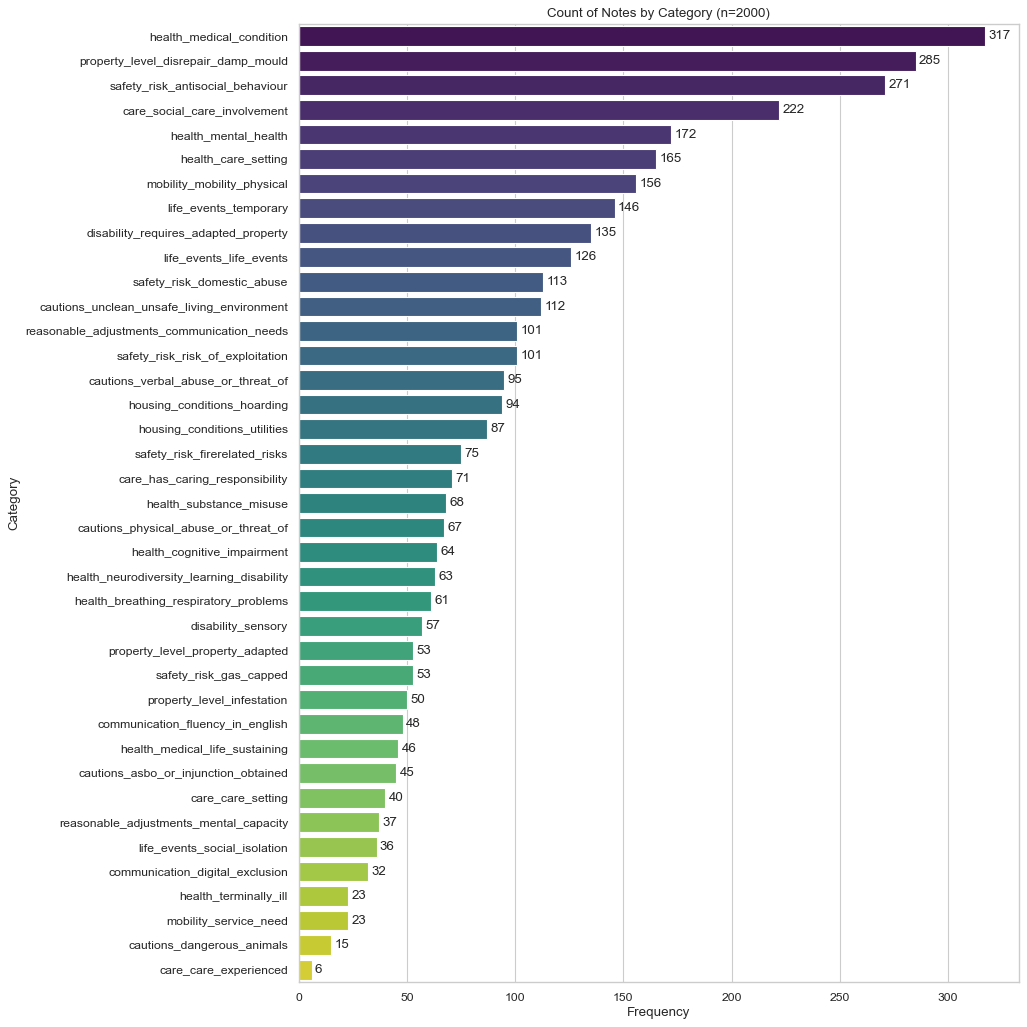

In [35]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records, taxonomy, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

 ## 4. Duplicate Handling & Agreement

 Group identical text contents, compute inter/intra-annotator agreement.

In [36]:
grouped = defaultdict(list)
for record in records:
    grouped[record["text"]].append(record)

y_true_docs, y_pred_docs = [], []
all_labels = set()

for duplicates in grouped.values():
    if len(duplicates) > 1:
        duplicates.sort(key=lambda x: x['annotation_date'], reverse=True)
        new, old = duplicates[0], duplicates[1]
        
        old_spans = [(span["start"], span["end"], span["label"]) for span in old.get('needs', []) + old.get('persons', [])]
        new_spans = [(span["start"], span["end"], span["label"]) for span in new.get('needs', []) + new.get('persons', [])]

        y_true_docs.append(old_spans)
        y_pred_docs.append(new_spans)
        all_labels.update([s[2] for s in old_spans + new_spans])

if all_labels:
    evaluator = SpanEvaluator(all_labels=all_labels, logger=config.logger)
    results = evaluator.evaluate(y_true_docs, y_pred_docs)
    evaluator.print_report(results, title="INTRA-ANNOTATOR AGREEMENT REPORT")


2026-07-01 17:40:48,056 | INFO | ==================================================================================================================================
2026-07-01 17:40:48,057 | INFO | INTRA-ANNOTATOR AGREEMENT REPORT
2026-07-01 17:40:48,058 | INFO | ==================================================================================================================================
2026-07-01 17:40:48,059 | INFO | Label                                         | L-P      L-R      L-F1     | S-P      S-R      S-F1    
2026-07-01 17:40:48,060 | INFO | ----------------------------------------------------------------------------------------------------------------------------------
2026-07-01 17:40:48,061 | INFO | Person_Name                                   | 0.925    0.947    0.936    | 0.885    0.906    0.895   
2026-07-01 17:40:48,061 | INFO | Person_Pronoun                                | 0.176    0.333    0.231    | 0.176    0.333    0.231   
2026-07-01 17:40:48,062 | INFO 

 ## 5. Class Imbalance Mitigation

 Merge low-prevalence labels to ensure models have enough training samples per class.
 The main targets for merging were examples with less than 40 examples.

In [37]:
MERGE_MAP = {
    "care_care_experienced": "life_events_life_events",
    "cautions_dangerous_animals": "safety_risk_antisocial_behaviour",
    "mobility_service_need": "mobility_mobility_physical",
    "health_medical_life_sustaining": "health_terminally_ill",
    "reasonable_adjustments_mental_capacity": "reasonable_adjustments_communication_needs",
    "life_events_social_isolation": "life_events_life_events",
}

taxonomy_v3 = taxonomy.copy()
taxonomy_v3['values_hint'] = taxonomy_v3['values_hint'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

labels_to_drop = set(MERGE_MAP.keys())
for old_label, new_label in MERGE_MAP.items():
    if old_label in taxonomy_v3['cat_label'].values and new_label in taxonomy_v3['cat_label'].values:
        old_idx = taxonomy_v3[taxonomy_v3['cat_label'] == old_label].index[0]
        new_idx = taxonomy_v3[taxonomy_v3['cat_label'] == new_label].index[0]
        
        taxonomy_v3.at[new_idx, 'regex'] = f"(?:{taxonomy_v3.at[old_idx, 'regex']})|(?:{taxonomy_v3.at[new_idx, 'regex']})"
        taxonomy_v3.at[new_idx, 'values_hint'] = taxonomy_v3.at[new_idx, 'values_hint'] + taxonomy_v3.at[old_idx, 'values_hint']

taxonomy_v3 = taxonomy_v3[~taxonomy_v3['cat_label'].isin(labels_to_drop)].reset_index(drop=True)

records_v2 = []
for record in records:
    new_record = copy.deepcopy(record)
    for ann in new_record.get("needs", []):
        if ann['label'] in labels_to_drop:
            ann['label'] = MERGE_MAP.get(ann['label'])
    for p in new_record.get('persons', []):
        # Merge all person labels into one person_ref.
        p['label'] = 'person_ref'
    records_v2.append(new_record)

### Show new distribution

,label,frequency,IRLbl
0,health_medical_condition,317,1.000000
1,property_level_disrepair_damp_mould,285,1.112281
2,safety_risk_antisocial_behaviour,281,1.128114
3,care_social_care_involvement,222,1.427928
4,health_mental_health,172,1.843023
5,mobility_mobility_physical,171,1.853801
6,health_care_setting,165,1.921212
7,life_events_life_events,162,1.956790
8,life_events_temporary,146,2.171233
9,reasonable_adjustments_communication_needs,135,2.348148


,Metric,Value
0,MeanIR,3.99
1,MaxIR,9.91
2,CVIR,0.54


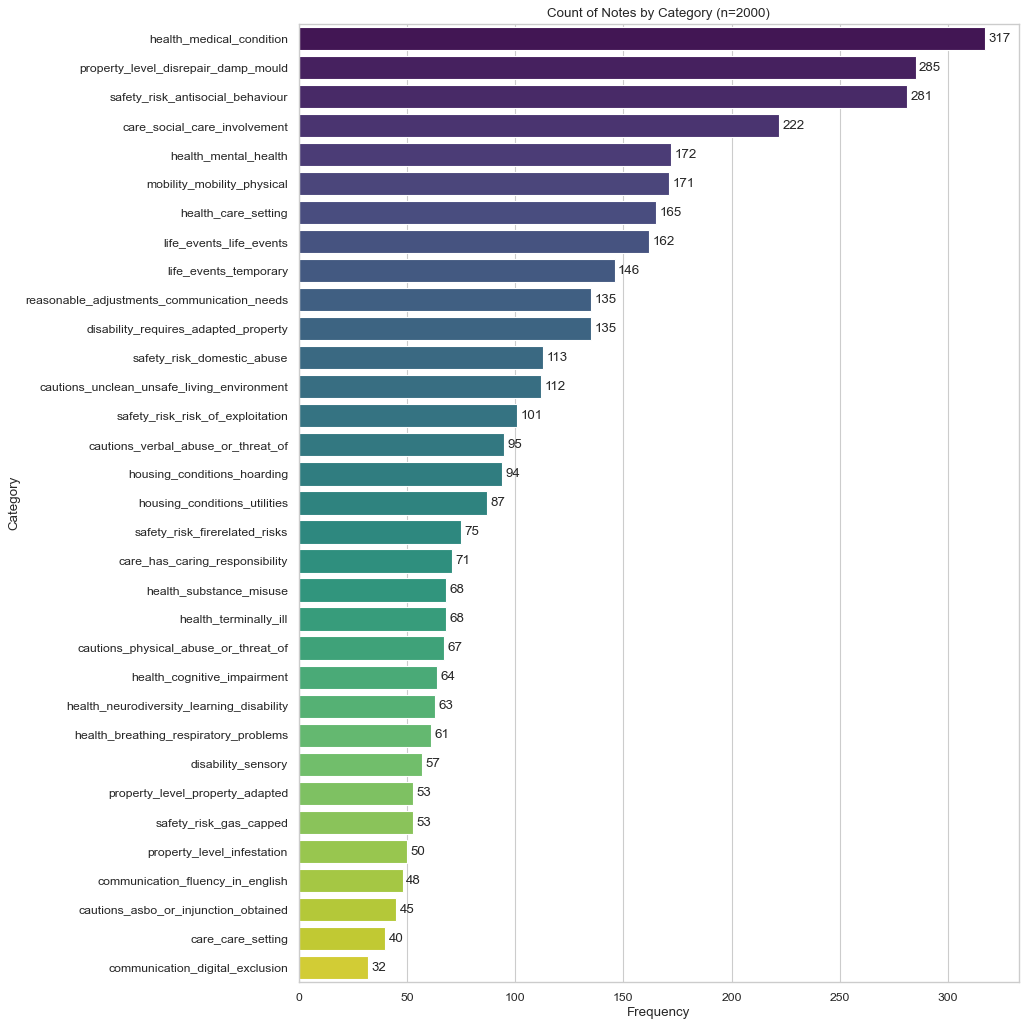

In [45]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records_v2, taxonomy_v3, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

## 7. Save as JSON

In [50]:
# Dump all
save_json(config.output_path, records_v2, config.logger)

2026-07-01 17:47:28,004 | INFO | Saving data to /Users/arawat/Desktop/CS3D6 Code/data/processed/gold_standard.json...
